# Customer Segmentation Analysis (RFM + K-Means)
**Author:** Minhaj Uddin Farhad
**Track:** Data Analytics (OIBSIP)
**Task:** Level 1 — Customer Segmentation Analysis

**Objective:** Apply clustering algorithms to segment the company's customer base into distinct groups based on purchasing behaviour (RFM: Recency, Frequency, Monetary), enabling targeted marketing strategies.

**Dataset:** Reusing the Superstore dataset from the EDA task — it has Customer ID, Order Date, and Sales, which is exactly what RFM analysis needs.

## Step 1: Load Data and Inspect Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"Shape: {df.shape}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print()
print("Missing values:")
print(df[['Customer ID', 'Order Date', 'Sales']].isnull().sum())

Shape: (9994, 21)
Unique customers: 793
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00

Missing values:
Customer ID    0
Order Date     0
Sales          0
dtype: int64


**Observation:** *(write your own take)*

No missing values in the columns we need (Customer ID, Order Date, Sales). Data spans about 4 years, with 793 unique customers across 5,009 orders — enough data to build meaningful customer-level behavioural features.

## Step 2: Descriptive Statistics

Before building RFM features, let's understand overall customer purchase behaviour: average purchase value, purchase frequency, and total customer lifetime value (total spend).

In [2]:
customer_summary = df.groupby('Customer ID').agg(
    total_orders=('Order ID', 'nunique'),
    total_spend=('Sales', 'sum'),
    avg_order_value=('Sales', 'mean')
)

print("Average purchase value (per line item):", round(df['Sales'].mean(), 2))
print("Average orders per customer:", round(customer_summary['total_orders'].mean(), 2))
print("Average customer lifetime value (total spend):", round(customer_summary['total_spend'].mean(), 2))
print()
customer_summary.describe()

Average purchase value (per line item): 229.86
Average orders per customer: 6.32
Average customer lifetime value (total spend): 2896.85



,total_orders,total_spend,avg_order_value
count,793.000000,793.000000,793.000000
mean,6.316520,2896.848500,227.868165
std,2.550885,2628.670117,190.342560
min,1.000000,4.833000,2.416500
25%,5.000000,1146.050000,115.520200
50%,6.000000,2256.394000,183.924000
75%,8.000000,3785.276000,282.688947
max,17.000000,25043.050000,1751.292000


**Observation:** *(write your own take)*

On average, each customer places around 6 orders and spends roughly $2,800 in total over the dataset's timeframe. There's a wide spread though — some customers are much higher-value than others, which is exactly what we want to capture with segmentation.

## Step 3: Feature Selection — Building RFM Features

We build the three classic RFM features, one row per customer:

- **Recency**: days since the customer's most recent order (lower = more recently active)
- **Frequency**: number of distinct orders placed
- **Monetary**: total amount spent

These three features together describe how valuable and active a customer is — which is exactly what a business needs to know to target marketing effectively.

In [3]:
# "Today" for recency purposes = the day after the last order in the dataset
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
rfm.head(10)

RFM table shape: (793, 4)


,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156
5,AB-10060,55,8,7755.620
6,AB-10105,42,10,14473.571
7,AB-10150,42,5,966.710
8,AB-10165,26,8,1113.838
9,AB-10255,167,9,914.532


**Observation:** *(write your own take)*

We now have one row per customer (793 rows) with their Recency, Frequency, and Monetary values. These three numbers are what we'll feed into K-Means clustering next.

## Step 4: Normalize/Standardize Before Clustering

Recency, Frequency, and Monetary are on very different scales (days vs. order count vs. dollars). K-Means uses distance between points, so without scaling, Monetary (which has the biggest numbers) would dominate the clustering. We use `StandardScaler` to put all three features on the same scale (mean 0, std 1).

In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

rfm_scaled.describe()

,Recency,Frequency,Monetary
count,7.930000e+02,7.930000e+02,7.930000e+02
mean,5.600116e-17,8.064167e-17,3.136065e-17
std,1.000631e+00,1.000631e+00,1.000631e+00
min,-7.888612e-01,-2.085502e+00,-1.100876e+00
25%,-6.276520e-01,-5.164289e-01,-6.664600e-01
50%,-3.858382e-01,-1.241606e-01,-2.437958e-01
75%,1.945149e-01,6.603760e-01,3.381893e-01
max,5.471429e+00,4.190791e+00,8.430186e+00


## Step 5: Apply K-Means — Elbow Method to Find Optimal K

We don't know in advance how many customer segments make sense. The Elbow Method tries K-Means with different numbers of clusters (K) and plots the "inertia" (how tightly packed each cluster is) for each. The "elbow" point — where adding more clusters stops giving a big improvement — is a good choice for K.

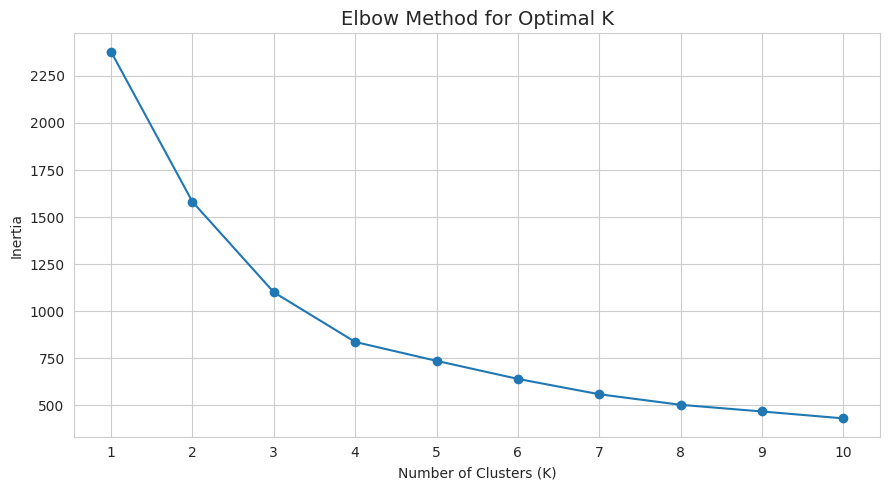

In [5]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take based on where the elbow actually appears in your chart)*

Looking at the chart, inertia drops sharply up to around K=4, after which the improvement flattens out significantly. This "elbow" suggests **K=4** is a reasonable choice — enough clusters to capture meaningful customer differences, without over-splitting the data into too many small, hard-to-interpret groups.

## Step 6: Apply K-Means with the Chosen K

In [6]:
optimal_k = 4  # based on the elbow plot above — change this if your elbow point looks different

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,185,5,5563.560,1
1,AA-10375,20,9,1056.390,0
2,AA-10480,260,4,1790.512,1
3,AA-10645,56,6,5086.935,0
4,AB-10015,416,3,886.156,3
5,AB-10060,55,8,7755.620,2
6,AB-10105,42,10,14473.571,2
7,AB-10150,42,5,966.710,1
8,AB-10165,26,8,1113.838,0
9,AB-10255,167,9,914.532,0


## Step 7: Visualize Clusters

We plot the clusters using two different feature-pair combinations, since we can't visualize all 3 RFM dimensions in a single 2D scatter plot at once.

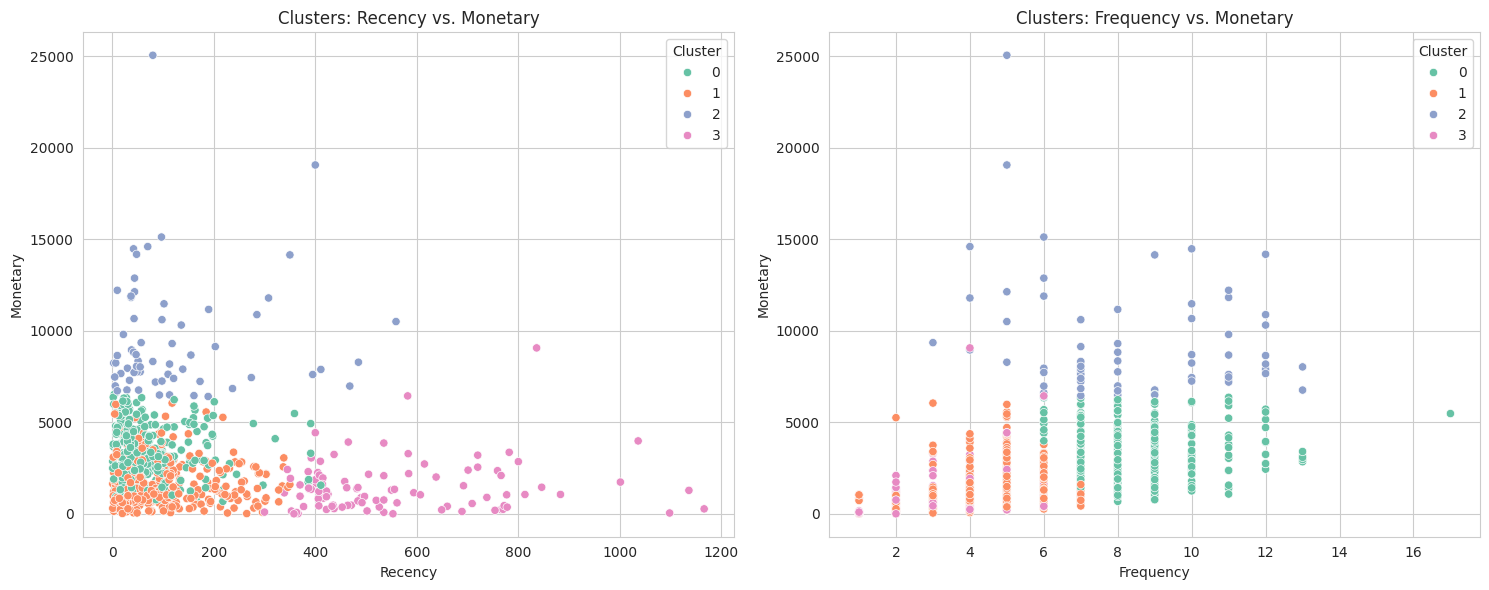

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0])
axes[0].set_title('Clusters: Recency vs. Monetary')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1])
axes[1].set_title('Clusters: Frequency vs. Monetary')

plt.tight_layout()
plt.show()

## Step 8: Profile Each Cluster

For each cluster, we calculate the average Recency, Frequency, and Monetary value, and use that to describe what kind of customer each cluster represents.

In [8]:
cluster_profile = rfm.groupby('Cluster').agg(
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean'),
    customer_count=('Customer ID', 'count')
).round(1)

cluster_profile

,avg_recency,avg_frequency,avg_monetary,customer_count
Cluster,,,,
0,72.7,8.5,3322.2,298
1,101.2,4.7,1669.7,335
2,123.7,8.3,9479.5,64
3,559.5,3.7,1470.2,96


**Cluster descriptions:** *(rewrite in your own words for the video/README — these are based on the actual output above)*

| Cluster | Avg Recency (days) | Avg Frequency | Avg Monetary ($) | Customers | Label |
|---|---|---|---|---|---|
| 2 | 123.7 | 8.3 | 9,479.5 | 64 | **Champions** — fewer customers, but by far the highest spenders and very frequent buyers |
| 0 | 72.7 | 8.5 | 3,322.2 | 298 | **Loyal / Regular** — most recently active, buy frequently, solid spend |
| 1 | 101.2 | 4.7 | 1,669.7 | 335 | **Occasional / Low-value** — largest group, buy less often and spend less |
| 3 | 559.5 | 3.7 | 1,470.2 | 96 | **At Risk / Churned** — haven't ordered in over a year and a half on average, low frequency |

This is a fairly typical RFM pattern: a small group of high-value "Champions" (Cluster 2), a large base of loyal regulars (Cluster 0), a bigger group of low-engagement occasional buyers (Cluster 1), and a clearly disengaged at-risk group (Cluster 3, with recency over 550 days — more than a year and a half since their last order).

## Step 9: Customers per Cluster

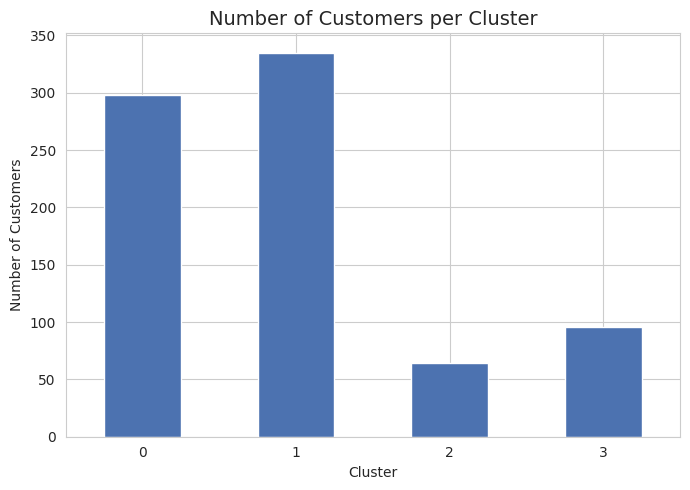

In [9]:
plt.figure(figsize=(7, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='#4C72B0')
plt.title('Number of Customers per Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 10: Insights — Marketing Recommendations per Segment

*(Write your own version for the video/README — mapped to the actual clusters found above.)*

1. **Cluster 2 — Champions (64 customers, avg spend $9,480)** — reward with a loyalty program, early access to new products, or exclusive discounts. This small group likely drives a disproportionate share of total revenue, so retaining them is the top priority.
2. **Cluster 0 — Loyal / Regular (298 customers)** — upsell and cross-sell campaigns to push them toward "Champion" status; personalized recommendations based on past purchases.
3. **Cluster 1 — Occasional / Low-value (335 customers, the largest group)** — general nurture campaigns (newsletters, seasonal promotions) aimed at increasing purchase frequency without heavy spend per customer.
4. **Cluster 3 — At Risk / Churned (96 customers, avg recency 559 days)** — win-back email campaigns with a special discount, or a short survey asking why they stopped purchasing. Since they haven't ordered in well over a year on average, a strong incentive may be needed to re-engage them.